# Object Detection - Graphical Degrading and Object Detection

## Steps for Part 1 - Graphical Degrading
1. Download zip code from assignment repository
1. Download the yolov3.weights from the readme in the github repository (This file is too big for github versioning)
1. Edit/Create an git "exclude" file in the main portfolio directory ".git/info".  Add "yolov3.weights" on a line by itself.  This avoids a git push failure due to the size of the file.
1. Fill in the missing code in this notebook  (You will need the working code examples to do the next step)
1. Create a python class that allows the following
   - Reads in the image
   - Create a loop that alters individual changes of the items below to determine names of identified objects and their confidence (down to when the object detetion is lost).  Remember to reset the image through each pass as they are not iterative.
     - size
     - rotation
     - noise (of your choice)
   - Graph the results
   
## Steps for Part 2 - Object Detection
1.  Generate a web interface python script that ingests a POST command of a picture Use [postman](https://www.postman.com/) to generate the post with picture of your choice.
1.  Returns the items detected and the assocated confidence
1.  Add to your python class above to offer this capability
1.  Test web interface locally
1.  Create a Dockerfile and build the image
1.  Test the Dockerfile locally
1.  Push notebook, python script, readme, etc to your github portfolio (since you are in the right location locally you just need to do a push at the main directory of the portfolio (after git add * and git commit -m " comment)
1.  Push locally built and test docker image to your docker hub portfolio.  Manually add to docker readme.
1.  Submit the two links (github Assignment5 directory and docker hub) via text submission to Canvas.

## Initial Start
* Load Libraries (Need to install wandb and cv2 - see below)
* plot_cv_image( img ) allows output of image within a notebook

In [ ]:
!pip install opencv-python-headless
!pip install wandb
!pip install matplotlib
!pip install scikit-image

In [1]:
import cv2 as cv
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt 
from copy import deepcopy


def plot_cv_img(input_image):     
    """     
    Converts an image from BGR to RGB and plots     
    """   
    # change color channels order for matplotlib     
    plt.imshow(cv.cvtColor(input_image, cv.COLOR_BGR2RGB))          

    # For easier view, turn off axis around image     
    plt.axis('off')  
    # Must save prior to show - for show clears the image!
    #plt.savefig("DetectionOutput.jpg")
    plt.show()

## Load Yolo Model

In [ ]:
# load yolo
net = cv.dnn.readNet("yolov3.weights",
                     "yolov3.cfg") #note weights to too big for github must save within readme

## Identify the number of layers in the model and their names

In [ ]:
ln = net.getLayerNames()
print(len(ln), ln)

## Read in and print out the categories for Yolo

In [ ]:
classes = []
with open("coco.names", 'r') as f:
    classes = [line.strip() for line in f.readlines()]
print(len(classes))
print(classes)

## Read in an image and output its dimensions

In [ ]:
img = cv.imread("Pictures/bermuda.jpg")
print("Original Shape: ", img.shape)
height, width, channel = img.shape
plot_cv_img(img)

## Resize the image and output its dimensions

In [ ]:
dsize = (512, 512)
img = cv.resize(img, dsize, interpolation=cv.INTER_LANCZOS4)  # Add code to resize
height, width, channel = img.shape
print("Resized Shape: ", img.shape)
plot_cv_img(img)

## Rotate the image using cv

In [ ]:
# Rotate
center = (width//2, height//2)
print(center)
rot_mat = cv.getRotationMatrix2D(center=center, angle=45, scale=1).astype('float32')  # add code to rotate
rotated_img = cv.warpAffine(src=img, M=rot_mat, dsize=dsize)
# print(rotated_img)
# print(type(rotated_img))
plot_cv_img(rotated_img)

## Rotate the image using scipy (might have to install if necessary)

In [ ]:
# Rotate
from scipy import ndimage
rotated_img = ndimage.rotate(img,  45, axes=(0, 1)) # add code to rotate
plot_cv_img(rotated_img)

## Add Salt and Pepper Noise

In [ ]:
#add salt and pepper noise
from skimage.util import random_noise
# Add salt-and-pepper noise to the image.

noise_img = random_noise(image=img, mode='s&p')  # add code to add salt and pepper noise
 
# The above function returns a floating-point image
# on the range [0, 1], thus we changed it to 'uint8'
# and from [0,255]

noise_img = np.array(255*noise_img, dtype = 'uint8')

plot_cv_img(noise_img)

## Add Gaussian noise

In [ ]:
import numpy as np
# gauss = np.random.normal(np.mean(img), np.std(img), img.shape) # add code  to add gaussian noise
gauss = np.random.normal(0, 5, img.shape) # add code  to add gaussian noise
gauss = gauss.reshape(img.shape[0],img.shape[1],img.shape[2]).astype('uint8')

# Add the Gaussian noise to the image
img_gauss = cv.add(img, gauss)  # Add the noise to the image
# Display the image
plot_cv_img(img_gauss)

## Add Speckle Noise with color

In [ ]:
#Speckle Noise
import numpy as np
 
img = cv.imread('Pictures/bermuda.jpg')
 
gauss = np.random.randn(img.shape[0], img.shape[1], img.shape[2])  # add code to add speckle noise
gauss = gauss.reshape(img.shape[0],img.shape[1],img.shape[2]).astype('uint8')
# speckle_img = cv.add(img, np.multiply(img, gauss))
speckle_img = cv.add(img, np.multiply(img, gauss))
plot_cv_img(speckle_img )

## Set up layers and colors

In [ ]:
layer_name = net.getLayerNames()
output_layer = [layer_name[i - 1] for i in net.getUnconnectedOutLayers()]
colors = np.random.uniform(0, 255, size=(len(classes), 3))

In [ ]:
print(output_layer)

In [ ]:
np.max(img)

In [ ]:
img.shape

## Fire up Model

In [ ]:
#note - 0.00392 = 1/250   416 is a standard square for yolo
blob = cv.dnn.blobFromImage(image=img,
                           scalefactor=1/np.max(img),
                           size=(416,416))  # Fill in other fields to create image compatible with cv

#detect objects
net.setInput(blob)
outs = net.forward(output_layer)

## Set up image on screen  (all done for you)
* Note how to extract the identified objects and their assocated confidence.  You need that for part 2 of this assignment

In [ ]:
# Showing Information on the screen
class_ids = []
confidences = []
boxes = []
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            # Object detection
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)
            # cv.circle(img, (center_x, center_y), 10, (0, 255, 0), 2 )
            # Reactangle Cordinate
            x = int(center_x - w/2)
            y = int(center_y - h/2)
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)
           
print("Type: ", type(class_ids))

indexes = cv.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
print(indexes)

font = cv.FONT_HERSHEY_PLAIN
for i in range(len(boxes)):
    if i in indexes:
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])
        print(f'Object: {label} with confidence of {confidences[i]:.2f}')
        color = colors[i]
        cv.rectangle(img, (x, y), (x + w, y + h), color, 2)
        cv.putText(img, label, (x, y + 30), font, 3, color, 3)

plot_cv_img(img)

In [2]:
class Degrader:
    """
    A class to detect objects in an image, and to stress-test the detection ability after image manipulation.
    """
    def __init__(self):
        self.img = None  # The image to work with
        self.net = cv.dnn.readNet("yolov3.weights", "yolov3.cfg")  # the CNN
        with open("coco.names", 'r') as f:
            self.classes = [line.strip() for line in f.readlines()]
        self.colors = None
        self.dsize = (416, 416)

        
    def setup_outs(self, img):
        """
        Get the YoloV3 output for an image.
        
        used by:
        procsingle(), shrink(), rotate(), noise()
        
        parameters:
        img (numpy array): The image to be ingested into YoloV3
        
        returns:
        outs (tuple of numpy array): The YoloV3 output
        """
        layer_name = self.net.getLayerNames()
        output_layer = [layer_name[i - 1] for i in self.net.getUnconnectedOutLayers()]
        self.colors = np.random.uniform(0, 255, size=(len(self.classes), 3))
        blob = cv.dnn.blobFromImage(image=img,
                                   scalefactor=1/np.max(img),
                                   size=self.dsize)
        #detect objects
        self.net.setInput(blob)
        outs = self.net.forward(output_layer)
        
        return outs
                                    
    
    def pred(self, outs):
        """
        Get the bounding box locations, prediction labels, and prediction confidences
        from the YoloV3 output.
        
        used by:
        procsingle(), shrink(), rotate(), noise()
        
        parameters:
        outs (tuple of numpy array): The YoloV3 output
        
        returns:
        objs (list of str): The detected object labels
        confs (list of float): The detection confidences
        output (str): The string output for the web service
        """
        class_ids = []
        confidences = []
        boxes = []
        height = self.dsize[0]
        width = self.dsize[1]
        # get the bounding boxes
        for out in outs:
            for detection in out:
                scores = detection[5:]
                class_id = np.argmax(scores)
                confidence = scores[class_id]
                if confidence > 0.5:
                    # Object detection
                    center_x = int(detection[0] * width)
                    center_y = int(detection[1] * height)
                    w = int(detection[2] * width)
                    h = int(detection[3] * height)
                    # Reactangle Cordinate
                    x = int(center_x - w/2)
                    y = int(center_y - h/2)
                    boxes.append([x, y, w, h])
                    confidences.append(float(confidence))
                    class_ids.append(class_id)

        indexes = cv.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

        objs = []
        confs = []
        font = cv.FONT_HERSHEY_PLAIN
        output = ''
        # get associated information from the bounding boxes
        for i in range(len(boxes)):
            if i in indexes:
                x, y, w, h = boxes[i]
                label = str(self.classes[class_ids[i]])
                objs.append(label)
                output += f'Object: {label} @confidence: {confidences[i]:.2f}, '
                confs.append(confidences[i])
                color = self.colors[i]
                cv.rectangle(self.img, (x, y), (x + w, y + h), color, 2)
                cv.putText(self.img, label, (x, y + 30), font, 3, color, 3)
                
        return objs, confs, output
    
    
    def procsingle(self):
        """
        Process a single image and detect objects.
        
        uses:
        setup_outs(), pred()
        
        returns:
        output (str): The string output for the web service
        """
        self.img = cv.imread('./Pictures/recimg')
        outs = self.setup_outs(self.img)
        _, _, output = self.pred(outs)
        
        return output
                
        
    def plotdeg(self, allobjs, allconfs, params, meas, activity):
        """
        Plot the prediction confidence vs image manipulation, and identify
        points of prediction loss.
        
        used by:
        manipulate()
        
        parameters:
        allobjs (list of list of str): The objects identified at each manipulation parameter value
        allconfs (list of list of float): The prediction confidence at each manipulation parameter value
        params (list of float): The manipulation parameter values
        meas (str): The parameter being manipulated
        activity (str): The description of the manipulation activity
        """
        maxlen = np.max([len(allobj) for allobj in allobjs])
        objsac = [[] for i in range(0, maxlen)]  # each object at each parameter value
        confsac = deepcopy(objsac)  # each confidence level at each parameter value
        paramsac = deepcopy(objsac)  # the parameter values with a prediction
        paramsls = [deepcopy(params) for i in range(0, maxlen)]  # parameter values with prediction lost
        # create a list for each object and its confidence at each parameter value
        for objs, confs, param in zip(allobjs, allconfs, params):
            for i, (obj, conf) in enumerate(zip(objs, confs)):
                objsac[i].append(obj)
                confsac[i].append(conf)
                paramsac[i].append(param)
                paramsls[i].remove(param)  # also record the parameters at which prediction was lost
        
        # For each object detected, plot the prediction confidences (or lack of) across manipulation params
        for i, (objac, confac, paramac, paramls) in\
                enumerate(zip(objsac, confsac, paramsac, paramsls)):
            label = '{}_{}'.format(objac[0], i)
            print('{} lost at {}: {}'.format(label, meas, paramls))
            plt.scatter(paramac,
                     confac,
                     label = label)
            
        plt.xlabel(meas)
        plt.xticks(params, rotation='vertical')
        plt.ylabel('prediction confidence')
        plt.title('Prediction Confidence Degradation According to {}'.\
                  format(activity))
        if activity == 'Size Reduction':
            plt.gca().invert_xaxis()
        plt.legend()
        plt.grid(True, linewidth=1, linestyle='dashdot')
        plt.show()
        
        
    def shrink(self):
        """
        Shrink the object according to a scaling factor
        
        uses:
        setup_outs(), pred()
        
        used by:
        manipulate()
        
        returns:
        allobjs (list of list of str): The objects identified at each manipulation parameter value
        allconfs (list of list of float): The prediction confidence at each manipulation parameter value
        params (list of float): The manipulation parameter values
        """
        height = self.img.shape[0]
        width = self.img.shape[1]
        allobjs = []
        allconfs = []
        params = []
        for i in reversed(range(1, 21, 1)):
            param = i / 100
            ht = int(height * param)
            wd = int(width * param)
            img = deepcopy(self.img)
            nimg = cv.resize(img,
                             dsize=(ht, wd),
                             interpolation=cv.INTER_LANCZOS4)
            outs = self.setup_outs(nimg)
            objs, confs, _ = self.pred(outs)
            allobjs.append(objs)
            allconfs.append(confs)
            params.append(param)
        
        return allobjs, allconfs, params
        
    
    def rotate(self):
        """
        Rotate the object by degrees
        
        uses:
        setup_outs(), pred()
        
        used by:
        manipulate()
        
        returns:
        allobjs (list of list of str): The objects identified at each manipulation parameter value
        allconfs (list of list of float): The prediction confidence at each manipulation parameter value
        params (list of float): The manipulation parameter values
        """
        allobjs = []
        allconfs = []
        params = []
        for param in range(0, 360, 10):
            img = deepcopy(self.img)
            rotated_img = ndimage.rotate(img, param, axes=(0, 1))
            outs = self.setup_outs(rotated_img)
            objs, confs, _ = self.pred(outs)
            allobjs.append(objs)
            allconfs.append(confs)
            params.append(param)
            
        return allobjs, allconfs, params
    
    
    def noise(self):
        """
        Add gaussian noise by adjusting the noise standard deviation
        
        uses:
        setup_outs(), pred()
        
        used by:
        manipulate()
        
        returns:
        allobjs (list of list of str): The objects identified at each manipulation parameter value
        allconfs (list of list of float): The prediction confidence at each manipulation parameter value
        params (list of float): The manipulation parameter values
        """
        allobjs = []
        allconfs = []
        params = []
        for param in np.arange(0, 10.1, 0.5):
            img = deepcopy(self.img)
            gauss = np.random.normal(0, param, self.img.shape)
            gauss = gauss.reshape(self.img.shape[0],
                                  self.img.shape[1],
                                  self.img.shape[2]).astype('uint8')
            img_gauss = cv.add(img, gauss)
            outs = self.setup_outs(img_gauss)
            objs, confs, _ = self.pred(outs)
            allobjs.append(objs)
            allconfs.append(confs)
            params.append(param)
            
        return allobjs, allconfs, params
    
    
    def manipulate(self, imgpth):
        """
        Stress test YoloV3 by iteratively manipulating a candidate image.
        
        uses:
        shrink(), rotate(), noise(), plotdeg()
        
        parameters:
        imgpth (str): the path to the candidate image
        """
        self.img = cv.imread(imgpth)
        meass = ['scale factor', 'angle', 'std']
        activities = ['Size Reduction', 'Rotation', 'Noise Level']
        for meas, activity in zip(meass, activities):
            print('\nprocessing {}...'.format(activity))
            if activity == 'Size Reduction':
                allobjs, allconfs, params = self.shrink()
            elif activity == 'Rotation':
                allobjs, allconfs, params = self.rotate()
            elif activity == 'Noise Level':
                allobjs, allconfs, params = self.noise()
            self.plotdeg(allobjs, allconfs, params, meas, activity)
            
            

In [3]:
degrader = Degrader()

# Summary
### Note the point at which the resize of the image degrades the image where the model can no longer detect the objects.  Graph the degradation confidence.
### Note the point at which the Gaussian noise and the salt and peper noise degrades the image where the model can no longer detect the objects.  Graph the degradtion condifidence.

### Note techniques in the model and/or image that improve the object detection.

PUT YOUR ANSWERS below which includes additional markdown cells, graph outputs and working code cells


processing Size Reduction...
person_0 lost at scale factor: [0.03, 0.02, 0.01]
person_1 lost at scale factor: [0.04, 0.03, 0.02, 0.01]


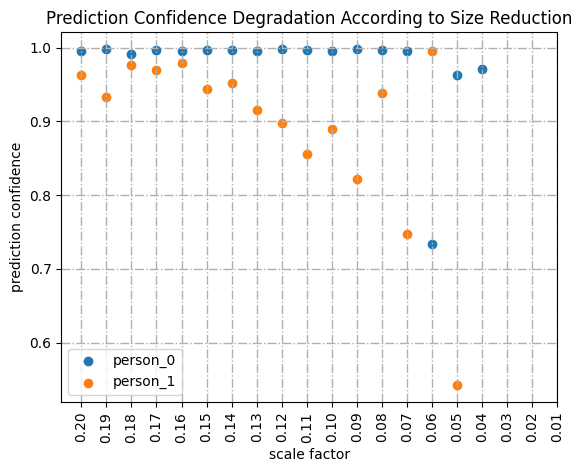


processing Rotation...
person_0 lost at angle: [100, 180, 190, 210, 230, 270, 280, 290, 300, 310]
person_1 lost at angle: [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330]


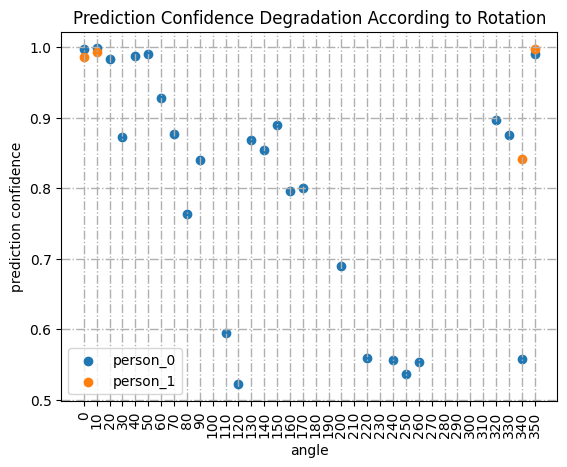


processing Noise Level...
person_0 lost at std: [6.5, 8.5]
person_1 lost at std: [2.0, 3.0, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
person_2 lost at std: [0.0, 0.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]


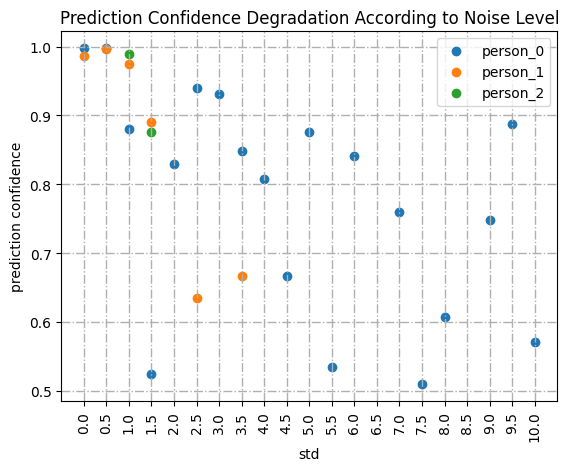

In [4]:
degrader.manipulate('Pictures/bermuda.jpg')

For resizing, the model began no longer detecting 2 persons once the size dropped below 8% of the original.  The model could no longer detect any persons once the size dropped below 4%.  We note that in the plot, indication of a single person being detected suggests only that the model can detect a single person, not that the model detects a specific person.

For rotation, the model could only detect 2 persons near the original angular orientation, from 340deg to 10deg.  For the remaining angles, the model could only detect 1 person, and this detection was intermittent.  The plot shows a complete loss of detection from 270-310deg.  

For noise addition, the presence of noise sometimes caused the model to detect a 3rd person.  This happened at a noise standard deviation of 1.0.  The model could detect no persons at noise standard deviations 6.5 and 8.5.